# Task-03
### Car Price Prediction with Machine learning

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
# Load Dataset

df = pd.read_csv("car data.csv")

In [4]:
# Showing loaded dataset
print("First 10 Records:\n")
print(df.head(10))

First 10 Records:

        Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0           ritz  2014           3.35           5.59       27000    Petrol   
1            sx4  2013           4.75           9.54       43000    Diesel   
2           ciaz  2017           7.25           9.85        6900    Petrol   
3        wagon r  2011           2.85           4.15        5200    Petrol   
4          swift  2014           4.60           6.87       42450    Diesel   
5  vitara brezza  2018           9.25           9.83        2071    Diesel   
6           ciaz  2015           6.75           8.12       18796    Petrol   
7        s cross  2015           6.50           8.61       33429    Diesel   
8           ciaz  2016           8.75           8.89       20273    Diesel   
9           ciaz  2015           7.45           8.92       42367    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dea

In [6]:
#Dataset Information
print("\nDataset Information:\n")
print(df.info())


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [7]:
# Convert categorical columns

df = pd.get_dummies(
    df,
    drop_first=True
)


In [8]:
car_data = df

In [10]:
# Features and Target

X = car_data.drop("Selling_Price", axis=1)
y = car_data["Selling_Price"]

In [11]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
# Model Training

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# Predictions

predictions = model.predict(X_test)

In [14]:
# Evaluation

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("\nModel Performance")

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)


Model Performance
MAE : 2.036517478989798
RMSE : 3.036624835478556
R2 Score : 0.5997023481942458


In [15]:
# Sample Prediction

sample = X.iloc[0:1]

predicted_price = model.predict(sample)

print("\nPredicted Car Price:", predicted_price[0])


Predicted Car Price: 3.8130245928448403


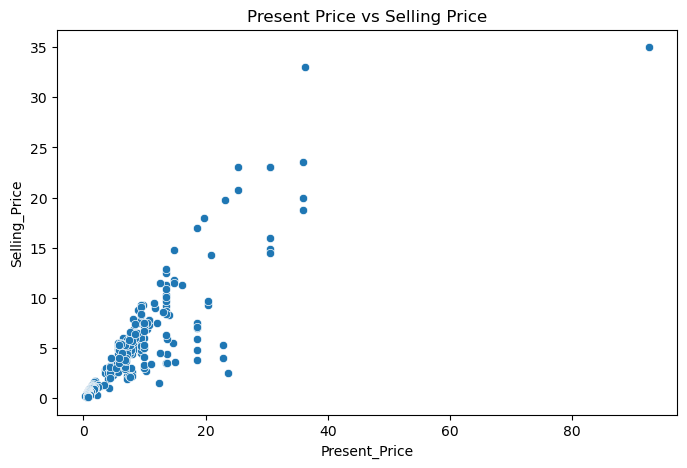

In [16]:
#Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Present_Price"],
    y=df["Selling_Price"]
)

plt.title("Present Price vs Selling Price")
plt.show()